# Portfolio 2: Reinforcement Learning — Gymnasium Taxi-v3

| | |
|---|---|
| **Vak** | Autonomous Systems |
| **Omgeving** | Gymnasium Taxi-v3 |
| **Algoritmen** | Q-learning, SARSA, Random Baseline |
| **Taal** | Python 3.10 |

## Samenvatting

Dit notebook implementeert en evalueert twee Reinforcement Learning (RL) algoritmen, Q-learning en SARSA, in de Gymnasium Taxi-v3 omgeving. Een random-policy baseline dient als vergelijkingspunt. Beide algoritmen zijn volledig zelf geïmplementeerd zonder gebruik te maken van bibliotheken waarin de algoritmen kant-en-klaar aangeboden worden. Hyperparameters zoals de learningrate ($α$), discountfactor ($γ$) en epsilon-decay ($ε$) worden systematisch geëxperimenteerd en vergeleken. De resultaten tonen aan dat beide RL-algoritmen de baseline significant overtreffen en een optimale policy leren voor het ophalen en afzetten van passagiers in een gesimuleerde stadsgrid.

## 1. Probleemstelling

### 1.1 De Taxi Omgeving

De Gymnasium Taxi-v3 omgeving (Dietterich, 2000; Gymnasium, 2023) is een klassiek RL-benchmark probleem. Een taxi rijdt rond in een 5×5 grid en moet een passagier ophalen op één van vier vaste locaties (R, G, Y, B) en naar de juiste bestemming brengen.

**Staatruimte:** 500 discrete staten, gecodeerd als:

$$
    staat = taxirij × 100 + taxikolom × 20 + passagierlocatie × 4 + bestemming
$$

- 25 taxiposities (5×5 grid)
- 5 passagierslocaties (4 vaste locaties + in de taxi)
- 4 bestemmingen

**Actieruimte:** 6 discrete acties:

| Actie | Beschrijving |
|-------|--------------|
| 0 | Rij naar het zuiden |
| 1 | Rij naar het noorden |
| 2 | Rij naar het oosten |
| 3 | Rij naar het westen |
| 4 | Haal passagier op |
| 5 | Zet passagier af |

**Beloningsstructuur:**

| Situatie | Beloning |
|----------|----------|
| Elke stap | −1 |
| Passagier succesvol afgezet | +20 |
| Illegale ophaal-/afzetpoging | −10 |

### 1.2 Probleemanalyse: Waarom Reinforcement Learning?

Het Taxi-probleem is bijzonder geschikt voor Reinforcement Learning om de volgende redenen:

**1. Sequentiële besluitvorming:** De agent moet een reeks opeenvolgende acties nemen waarbij vroege beslissingen gevolgen hebben voor latere situaties. RL is specifiek ontworpen voor dit soort Markov Decision Processes (Bellman, 1957; Sutton & Barto, 2018).

**2. Vertraagd beloningssignaal:** De beloning van +20 volgt pas na vele stappen. Supervised learning vereist gelabelde trainingsdata per stap, wat hier niet beschikbaar is.

**3. Geen expliciete model van de omgeving:** Er is geen formule beschikbaar die de optimale route berekent. RL leert dit empirisch via trial-and-error.

**4. Exploratie vs. exploitatie:** De agent moet nieuwe routes verkennen (exploratie) maar ook geleerde goede routes benutten (exploitatie).

**Vergelijking met alternatieve methoden:**

- *Supervised learning:* Vereist gelabelde voorbeelden van optimale acties per staat. Dit is niet beschikbaar zonder een expert-policy.
- *Rulebased systems:* Handmatig ontworpen regels zijn fragiel en schalen slecht.
- *RL:* Leert autonoom een optimale policy via interactie, zonder voorafgaande kennis van de omgevingsdynamica.

### 1.3 Doelstelling

1. Implementeer een random-policy baseline als ondergrens van prestatie.
2. Implementeer Q-learning (off-policy) en SARSA (on-policy) volledig vanuit scratch.
3. Experimenteer systematisch met hyperparameters ($α$, $γ$, $ε$-decay).
4. Vergelijk de prestaties op basis van gemiddelde beloning, succespercentage en convergentiesnelheid.

## 2. Theoretisch Kader

### 2.1 Basisconcepten van Reinforcement Learning

Reinforcement Learning is een leerparadigma waarbij een agent leert door interactie met een omgeving (Sutton & Barto, 2018). Het leerproces verloopt via een herhalende cyclus waarbij de agent in staat $s_t$ actie $a_t$ kiest, een beloning $r_{t+1}$ ontvangt en in de nieuwe staat $s_{t+1}$ terechtkomt.

De kerncomponenten zijn:

- **Staat** (*state*, $s$): De volledige beschrijving van de omgeving. In Taxi-v3: positie van de taxi, locatie van de passagier en de bestemming.
- **Actie** (*action*, $a$): De keuze van de agent. In Taxi-v3: één van de zes acties.
- **Beloning** (*reward*, $r$): Het feedbacksignaal van de omgeving na een actie.
- **Policy** ($π$): De strategie die de agent hanteert bij het kiezen van acties.
- **Actie-waarde-functie** $Q(s,a)$: De verwachte gecumuleerde beloning bij het nemen van actie a in staat s onder policy $π$.

### 2.2 Q-learning (Off-policy TD-control)

Q-learning (Watkins & Dayan, 1992) is een model-vrij, off-policy algoritme dat de optimale actie-waarde-functie Q*(s,a) leert. De updateformule is:

$$
    Q(s_t, a_t) <- Q(s_t, a_t) + α * [r_{t+1} + γ * max_a' Q(s_{t+1}, a') - Q(s_t, a_t)]
$$

waarbij:
- **$α ∈ (0,1]$**: learningrate bepaalt hoe snel nieuwe informatie wordt opgenomen
- **$γ ∈ [0,1]$**: discountfactor weegt toekomstige beloningen
- **$max_a' Q(s_{t+1}, a')$**: maximale Q-waarde in de volgende staat (greedy, off-policy)

De term tussen de haakjes heet de TD-fout: het verschil tussen de geschatte doelwaarde en de huidige schatting. Q-learning convergeert naar de optimale policy $π*$ mits alle staat-actie-paren voldoende bezocht worden (Watkins & Dayan, 1992).

### 2.3 SARSA (On-policy TD-control)

SARSA, State-Action-Reward-State-Action, (Rummery & Niranjan, 1994) is een on-policy algoritme. Het verschil met Q-learning is dat SARSA de daadwerkelijk gekozen volgende actie gebruikt:

$$
    Q(s_t, a_t) <- Q(s_t, a_t) + α * [r_{t+1} + γ * Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t)]
$$

Omdat $a_{t+1}$ gekozen wordt via de epsilon-greedy policy (inclusief exploratie), is SARSA conservatiever: de agent leert van zijn eigen gedrag, inclusief exploratiestappen.

### 2.4 Epsilon-greedy Exploratie

De exploratie-exploitatie-afweging wordt geregeld via epsilon-greedy (Tokic, 2010):

- Met kans $ε$: kies een willekeurige actie (exploratie)
- Met kans $1−ε$: kies de greedy actie $argmax_a Q(s_t, a)$ (exploitatie)

Tijdens training wordt $ε$ exponentieel verminderd: $ε_{t+1} = max(ε_{min}, ε_t × decayfactor)$.

## 3. Implementatie

### 3.1 Setup en Omgeving

In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time

# Reproduceerbare resultaten
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use('seaborn-v0_8')

print('Libraries succesvol geladen.')
print(f'Gymnasium versie: {gym.__version__}')

Libraries succesvol geladen.
Gymnasium versie: 1.3.0


In [6]:
# Maak de Taxi-v3 omgeving aan
env = gym.make('Taxi-v4')
obs, info = env.reset(seed=SEED)

n_states = env.observation_space.n
n_actions = env.action_space.n

ACTION_NAMES = {0: 'Zuid', 1: 'Noord', 2: 'Oost', 3: 'West', 4: 'Ophalen', 5: 'Afzetten'}

print('=' * 50)
print('Omgeving: Gymnasium Taxi-v3')
print('=' * 50)
print(f'Aantal staten:  {n_states}')
print(f'Aantal acties:  {n_actions}')
print()
print('Beschikbare acties:')
for idx, name in ACTION_NAMES.items():
    print(f'  {idx}: {name}')
print()
print(f'Beginstaat (gecodeerd): {obs}')
print()
print('Beloningsstructuur:')
print('  Elke stap:                    -1')
print('  Passagier succesvol afgezet: +20')
print('  Illegale ophaal-/afzetpoging: -10')

Omgeving: Gymnasium Taxi-v3
Aantal staten:  500
Aantal acties:  6

Beschikbare acties:
  0: Zuid
  1: Noord
  2: Oost
  3: West
  4: Ophalen
  5: Afzetten

Beginstaat (gecodeerd): 386

Beloningsstructuur:
  Elke stap:                    -1
  Passagier succesvol afgezet: +20
  Illegale ophaal-/afzetpoging: -10


### 3.2 Baseline Strategie: Random Policy

De baseline-strategie is een willekeurige policy: de agent kiest bij elke stap een uniform willekeurige actie uit de actieruimte. Deze policy implementeert geen leerproces en dient als ondergrens, een goed RL-algoritme moet deze baseline consistent overtreffen.

In [7]:
def evaluate_policy(env, policy_fn, n_episodes=1000, max_steps=200, seed=42):
    """
    Evalueer een policy over meerdere episodes.

    Parameters
    ----------
    env        : gymnasium.Env — de Taxi-v3 omgeving
    policy_fn  : callable     — neemt een staat, geeft een actie terug
    n_episodes : int          — aantal evaluatie-episodes
    max_steps  : int          — maximum stappen per episode (voorkomt eindeloze loops)
    seed       : int          — beginwaarde voor reproduceerbaarheid

    Returns
    -------
    dict met gemiddelde beloning, standaarddeviatie, stappen en succespercentage.
    """
    total_rewards = []
    total_steps = []
    successful_episodes = 0

    for episode in range(n_episodes):
        state, _ = env.reset(seed=seed + episode)
        done = False
        episode_reward = 0
        steps = 0

        while not done and steps < max_steps:
            action = policy_fn(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            steps += 1

        if terminated:  # terminated=True betekent succesvol afzetten bereikt
            successful_episodes += 1

        total_rewards.append(episode_reward)
        total_steps.append(steps)

    return {
        'rewards': total_rewards,
        'steps': total_steps,
        'mean_reward': np.mean(total_rewards),
        'std_reward': np.std(total_rewards),
        'mean_steps': np.mean(total_steps),
        'success_rate': successful_episodes / n_episodes,
    }

In [8]:
# Random policy: kies bij elke stap een willekeurige actie
random_policy = lambda state: env.action_space.sample()

print('Evaluatie van de random policy baseline (1000 episodes)...')
baseline_results = evaluate_policy(env, random_policy, n_episodes=1000, seed=SEED)

print()
print('=== Baseline: Random Policy ===')
print(f'Gemiddelde beloning: {baseline_results["mean_reward"]:.2f} \u00b1 {baseline_results["std_reward"]:.2f}')
print(f'Gemiddeld stappen:   {baseline_results["mean_steps"]:.1f}')
print(f'Succespercentage:    {baseline_results["success_rate"] * 100:.1f}%')

Evaluatie van de random policy baseline (1000 episodes)...

=== Baseline: Random Policy ===
Gemiddelde beloning: -771.22 ± 109.95
Gemiddeld stappen:   196.1
Succespercentage:    5.3%


### 3.3 Q-learning Agent

Q-learning is geïmplementeerd als een klasse met een Q-tabel van formaat 500 × 6. De tabel wordt geïnitialiseerd met nullen. De epsilon-greedy policy zorgt voor de exploratie-exploitatie-afweging. Na elk episode wordt epsilon vermenigvuldigd met de vervalfactor totdat de minimum-waarde bereikt is.

In [9]:
class QLearningAgent:
    """
    Q-Learning agent (off-policy TD-control).

    Update-regel (Watkins & Dayan, 1992):
        Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]
    """

    def __init__(
        self,
        n_states: int,
        n_actions: int,
        alpha: float = 0.1,
        gamma: float = 0.99,
        epsilon: float = 1.0,
        epsilon_decay: float = 0.995,
        epsilon_min: float = 0.01,
    ):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        # Q-tabel geinitialiseerd op nul: neutrale startpositie zonder aannames
        self.q_table = np.zeros((n_states, n_actions))

    def select_action(self, state: int) -> int:
        """Epsilon-greedy actieselectie."""
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        return int(np.argmax(self.q_table[state]))

    def update(
        self,
        state: int,
        action: int,
        reward: float,
        next_state: int,
        done: bool,
    ) -> None:
        """Update Q-waarde via de Bellman-vergelijking (off-policy: max over volgende acties)."""
        current_q = self.q_table[state, action]
        if done:
            td_target = reward
        else:
            td_target = reward + self.gamma * np.max(self.q_table[next_state])
        td_error = td_target - current_q
        self.q_table[state, action] += self.alpha * td_error

    def decay_epsilon(self) -> None:
        """Verklein epsilon exponentieel na elk episode."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def train(
        self,
        env,
        n_episodes: int = 10000,
        max_steps: int = 200,
        seed: int = 42,
        verbose: bool = True,
    ):
        """Train de Q-learning agent over n_episodes."""
        rewards_history = []
        steps_history = []
        epsilon_history = []

        for episode in range(n_episodes):
            state, _ = env.reset(seed=seed + episode)
            done = False
            total_reward = 0
            steps = 0

            while not done and steps < max_steps:
                action = self.select_action(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                self.update(state, action, reward, next_state, done)
                state = next_state
                total_reward += reward
                steps += 1

            self.decay_epsilon()
            rewards_history.append(total_reward)
            steps_history.append(steps)
            epsilon_history.append(self.epsilon)

            if verbose and (episode + 1) % 2000 == 0 or (episode == 0):
                avg = np.mean(rewards_history[-100:])
                print(
                    f'Episode {episode + 1:>6}/{n_episodes} | '
                    f'Gem. beloning (100 ep.): {avg:>7.2f} | '
                    f'Epsilon: {self.epsilon:.4f}'
                )

        return rewards_history, steps_history, epsilon_history

    def get_policy(self, state: int) -> int:
        """Greedy actie (puur exploitatie, geen exploratie)."""
        return int(np.argmax(self.q_table[state]))

In [10]:
N_EPISODES = 10000

q_agent = QLearningAgent(
    n_states=n_states,
    n_actions=n_actions,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01,
)

print('Q-learning training gestart...')
t0 = time.time()
q_rewards, q_steps, q_epsilon = q_agent.train(env, n_episodes=N_EPISODES, seed=SEED)
print(f'\nTraining voltooid in {time.time() - t0:.1f} seconden')

# Evalueer getrainde agent met puur greedy policy (geen exploratie)
q_results = evaluate_policy(env, q_agent.get_policy, n_episodes=1000, seed=SEED)

print()
print('=== Q-learning (na training, greedy policy) ===')
print(f'Gemiddelde beloning: {q_results["mean_reward"]:.2f} \u00b1 {q_results["std_reward"]:.2f}')
print(f'Gemiddeld stappen:   {q_results["mean_steps"]:.1f}')
print(f'Succespercentage:    {q_results["success_rate"] * 100:.1f}%')

Q-learning training gestart...
Episode      1/10000 | Gem. beloning (100 ep.): -731.00 | Epsilon: 0.9950
Episode   2000/10000 | Gem. beloning (100 ep.):    6.67 | Epsilon: 0.0100
Episode   4000/10000 | Gem. beloning (100 ep.):    7.17 | Epsilon: 0.0100
Episode   6000/10000 | Gem. beloning (100 ep.):    7.53 | Epsilon: 0.0100
Episode   8000/10000 | Gem. beloning (100 ep.):    6.55 | Epsilon: 0.0100
Episode  10000/10000 | Gem. beloning (100 ep.):    7.36 | Epsilon: 0.0100

Training voltooid in 7.5 seconden

=== Q-learning (na training, greedy policy) ===
Gemiddelde beloning: 7.86 ± 2.61
Gemiddeld stappen:   13.1
Succespercentage:    100.0%


### 3.4 SARSA Agent

SARSA verschilt van Q-learning in de update-stap: in plaats van de maximale Q-waarde van de volgende staat te gebruiken, gebruikt SARSA de Q-waarde van de daadwerkelijk gekozen volgende actie. Dit maakt SARSA on-policy: de agent leert de waarde van dezelfde policy die hij uitvoert, inclusief de exploratiestappen. Hierdoor is SARSA doorgaans voorzichtiger bij handelingen met hoge risico's (zoals illegale ophaal-/afzetpogingen).

In [11]:
class SARSAAgent:
    """
    SARSA agent (on-policy TD-control).

    Update-regel (Rummery & Niranjan, 1994):
        Q(s,a) <- Q(s,a) + alpha * [r + gamma * Q(s',a') - Q(s,a)]

    Kernverschil met Q-learning: a' is de daadwerkelijk gekozen actie
    (on-policy), niet de greedy actie (off-policy).
    """

    def __init__(
        self,
        n_states: int,
        n_actions: int,
        alpha: float = 0.1,
        gamma: float = 0.99,
        epsilon: float = 1.0,
        epsilon_decay: float = 0.995,
        epsilon_min: float = 0.01,
    ):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = np.zeros((n_states, n_actions))

    def select_action(self, state: int) -> int:
        """Epsilon-greedy actieselectie."""
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        return int(np.argmax(self.q_table[state]))

    def update(
        self,
        state: int,
        action: int,
        reward: float,
        next_state: int,
        next_action: int,
        done: bool,
    ) -> None:
        """Update Q-waarde via SARSA Bellman-vergelijking (on-policy: gebruik a')."""
        current_q = self.q_table[state, action]
        if done:
            td_target = reward
        else:
            # On-policy: gebruik Q-waarde van de daadwerkelijk gekozen volgende actie
            td_target = reward + self.gamma * self.q_table[next_state, next_action]
        td_error = td_target - current_q
        self.q_table[state, action] += self.alpha * td_error

    def decay_epsilon(self) -> None:
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def train(
        self,
        env,
        n_episodes: int = 10000,
        max_steps: int = 200,
        seed: int = 42,
        verbose: bool = True,
    ):
        """Train de SARSA agent (on-policy: kies a' voor de update)."""
        rewards_history = []
        steps_history = []
        epsilon_history = []

        for episode in range(n_episodes):
            state, _ = env.reset(seed=seed + episode)
            # SARSA: kies de eerste actie al voor de lus (S,A,R,S',A' schema)
            action = self.select_action(state)
            done = False
            total_reward = 0
            steps = 0

            while not done and steps < max_steps:
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                # Kies volgende actie via epsilon-greedy (on-policy)
                next_action = self.select_action(next_state)
                self.update(state, action, reward, next_state, next_action, done)
                state = next_state
                action = next_action
                total_reward += reward
                steps += 1

            self.decay_epsilon()
            rewards_history.append(total_reward)
            steps_history.append(steps)
            epsilon_history.append(self.epsilon)

            if verbose and (episode + 1) % 2000 == 0 or (episode == 0):
                avg = np.mean(rewards_history[-100:])
                print(
                    f'Episode {episode + 1:>6}/{n_episodes} | '
                    f'Gem. beloning (100 ep.): {avg:>7.2f} | '
                    f'Epsilon: {self.epsilon:.4f}'
                )

        return rewards_history, steps_history, epsilon_history

    def get_policy(self, state: int) -> int:
        return int(np.argmax(self.q_table[state]))

In [12]:
sarsa_agent = SARSAAgent(
    n_states=n_states,
    n_actions=n_actions,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01,
)

print('SARSA training gestart...')
t0 = time.time()
sarsa_rewards, sarsa_steps, sarsa_epsilon = sarsa_agent.train(env, n_episodes=N_EPISODES, seed=SEED)
print(f'\nTraining voltooid in {time.time() - t0:.1f} seconden')

sarsa_results = evaluate_policy(env, sarsa_agent.get_policy, n_episodes=1000, seed=SEED)

print()
print('=== SARSA (na training, greedy policy) ===')
print(f'Gemiddelde beloning: {sarsa_results["mean_reward"]:.2f} \u00b1 {sarsa_results["std_reward"]:.2f}')
print(f'Gemiddeld stappen:   {sarsa_results["mean_steps"]:.1f}')
print(f'Succespercentage:    {sarsa_results["success_rate"] * 100:.1f}%')

SARSA training gestart...
Episode      1/10000 | Gem. beloning (100 ep.): -848.00 | Epsilon: 0.9950
Episode   2000/10000 | Gem. beloning (100 ep.):    5.79 | Epsilon: 0.0100
Episode   4000/10000 | Gem. beloning (100 ep.):    7.04 | Epsilon: 0.0100
Episode   6000/10000 | Gem. beloning (100 ep.):    7.35 | Epsilon: 0.0100
Episode   8000/10000 | Gem. beloning (100 ep.):    6.41 | Epsilon: 0.0100
Episode  10000/10000 | Gem. beloning (100 ep.):    7.05 | Epsilon: 0.0100

Training voltooid in 5.7 seconden

=== SARSA (na training, greedy policy) ===
Gemiddelde beloning: 7.55 ± 2.92
Gemiddeld stappen:   13.4
Succespercentage:    100.0%


## 4. Hyperparameter Experimenten

Drie hyperparameters worden systematisch geëxperimenteerd met Q-learning als algoritme:

| Parameter | Beschrijving | Geteste waarden |
|-----------|-------------|------------------|
| $α$ (alpha) | Leersnelheid: hoe snel nieuwe informatie de Q-waarden overschrijft | 0.01, 0.1, 0.5, 0.9 |
| $γ$ (gamma) | Kortingsfactor: gewicht van toekomstige beloningen | 0.5, 0.8, 0.95, 0.99 |
| $ε$-decay | Tempo van epsilon-afname (exploratie → exploitatie) | 0.990, 0.995, 0.999, 0.9995 |

Elk experiment traint 5.000 episodes met één variabele parameter; overige parameters staan op hun standaardwaarden ($α$=0.1, $γ$=0.99, $ε$-decay=0.995).

In [13]:
def smooth(data, window=100):
    """Voortschrijdend gemiddelde voor vloeiende visualisatie van het leerverloop."""
    arr = np.array(data)
    return np.array([
        arr[max(0, i - window + 1): i + 1].mean()
        for i in range(len(arr))
    ])


def run_hyperparameter_experiment(param_name, param_values, n_episodes=5000, seed=42, **fixed_kwargs):
    """
    Voer een hyperparameter-sweep uit voor Q-learning.

    Parameters
    ----------
    param_name   : str  — naam van de te variëren parameter
    param_values : list — te testen waarden
    n_episodes   : int  — episodes per configuratie
    seed         : int  — beginwaarde
    **fixed_kwargs      — vaste waarden voor overige parameters

    Returns
    -------
    dict : {param_value: rewards_lijst}
    """
    results = {}
    for value in param_values:
        kwargs = dict(fixed_kwargs)
        kwargs[param_name] = value
        agent = QLearningAgent(n_states=n_states, n_actions=n_actions, **kwargs)
        rewards, _, _ = agent.train(env, n_episodes=n_episodes, seed=seed, verbose=False)
        results[value] = rewards
        final_avg = np.mean(rewards[-100:])
        print(f'  {param_name}={value}: gem. beloning (laatste 100 ep.) = {final_avg:.2f}')
    return results


COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

=== Experiment 1: Learning rate (alpha) ===
Episode      1/5000 | Gem. beloning (100 ep.): -650.00 | Epsilon: 0.9950
  alpha=0.01: gem. beloning (laatste 100 ep.) = -60.09
Episode      1/5000 | Gem. beloning (100 ep.): -767.00 | Epsilon: 0.9950
  alpha=0.1: gem. beloning (laatste 100 ep.) = 7.01
Episode      1/5000 | Gem. beloning (100 ep.): -659.00 | Epsilon: 0.9950
  alpha=0.5: gem. beloning (laatste 100 ep.) = 7.19
Episode      1/5000 | Gem. beloning (100 ep.): -821.00 | Epsilon: 0.9950
  alpha=0.9: gem. beloning (laatste 100 ep.) = 7.26


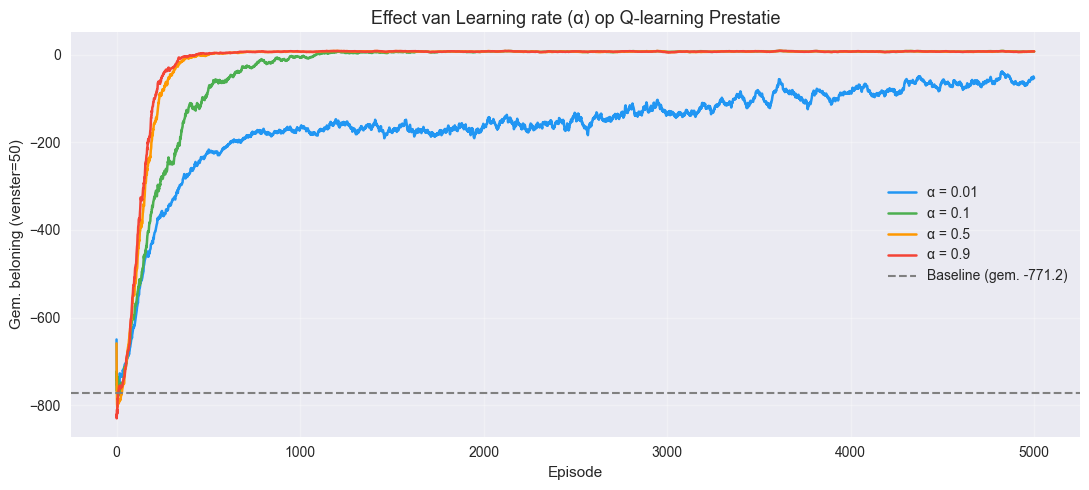

Opgeslagen: alpha_experiment.png


In [14]:
print('=== Experiment 1: Learning rate (alpha) ===')
alpha_values = [0.01, 0.1, 0.5, 0.9]
alpha_results = run_hyperparameter_experiment(
    'alpha', alpha_values, n_episodes=5000, seed=SEED,
    gamma=0.99, epsilon_decay=0.995,
)

fig, ax = plt.subplots(figsize=(11, 5))
for (alpha, rewards), color in zip(alpha_results.items(), COLORS):
    ax.plot(smooth(rewards, 50), label=f'\u03b1 = {alpha}', color=color, linewidth=1.8)
ax.axhline(
    y=baseline_results['mean_reward'], color='gray', linestyle='--', linewidth=1.5,
    label=f'Baseline (gem. {baseline_results["mean_reward"]:.1f})'
)
ax.set_title('Effect van Learning rate (\u03b1) op Q-learning Prestatie', fontsize=13)
ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel('Gem. beloning (venster=50)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('alpha_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Opgeslagen: alpha_experiment.png')

=== Experiment 2: Discount factor (gamma) ===
Episode      1/5000 | Gem. beloning (100 ep.): -857.00 | Epsilon: 0.9950
  gamma=0.5: gem. beloning (laatste 100 ep.) = 5.53
Episode      1/5000 | Gem. beloning (100 ep.): -794.00 | Epsilon: 0.9950
  gamma=0.8: gem. beloning (laatste 100 ep.) = 7.11
Episode      1/5000 | Gem. beloning (100 ep.): -731.00 | Epsilon: 0.9950
  gamma=0.95: gem. beloning (laatste 100 ep.) = 7.36
Episode      1/5000 | Gem. beloning (100 ep.): -938.00 | Epsilon: 0.9950
  gamma=0.99: gem. beloning (laatste 100 ep.) = 7.14


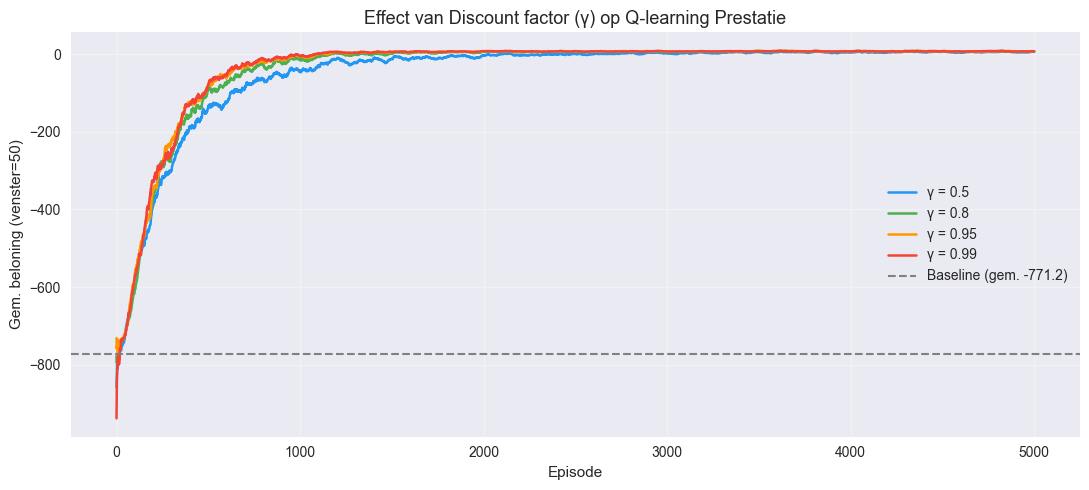

Opgeslagen: gamma_experiment.png


In [15]:
print('=== Experiment 2: Discount factor (gamma) ===')
gamma_values = [0.5, 0.8, 0.95, 0.99]
gamma_results = run_hyperparameter_experiment(
    'gamma', gamma_values, n_episodes=5000, seed=SEED,
    alpha=0.1, epsilon_decay=0.995,
)

fig, ax = plt.subplots(figsize=(11, 5))
for (gamma, rewards), color in zip(gamma_results.items(), COLORS):
    ax.plot(smooth(rewards, 50), label=f'\u03b3 = {gamma}', color=color, linewidth=1.8)
ax.axhline(
    y=baseline_results['mean_reward'], color='gray', linestyle='--', linewidth=1.5,
    label=f'Baseline (gem. {baseline_results["mean_reward"]:.1f})'
)
ax.set_title('Effect van Discount factor (\u03b3) op Q-learning Prestatie', fontsize=13)
ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel('Gem. beloning (venster=50)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gamma_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Opgeslagen: gamma_experiment.png')

=== Experiment 3: Epsilon-decay ===
Episode      1/5000 | Gem. beloning (100 ep.): -794.00 | Epsilon: 0.9900
  epsilon_decay=0.99: gem. beloning (laatste 100 ep.) = 7.19
Episode      1/5000 | Gem. beloning (100 ep.): -857.00 | Epsilon: 0.9950
  epsilon_decay=0.995: gem. beloning (laatste 100 ep.) = 6.92
Episode      1/5000 | Gem. beloning (100 ep.): -884.00 | Epsilon: 0.9990
  epsilon_decay=0.999: gem. beloning (laatste 100 ep.) = 6.99
Episode      1/5000 | Gem. beloning (100 ep.): -794.00 | Epsilon: 0.9995
  epsilon_decay=0.9995: gem. beloning (laatste 100 ep.) = 2.62


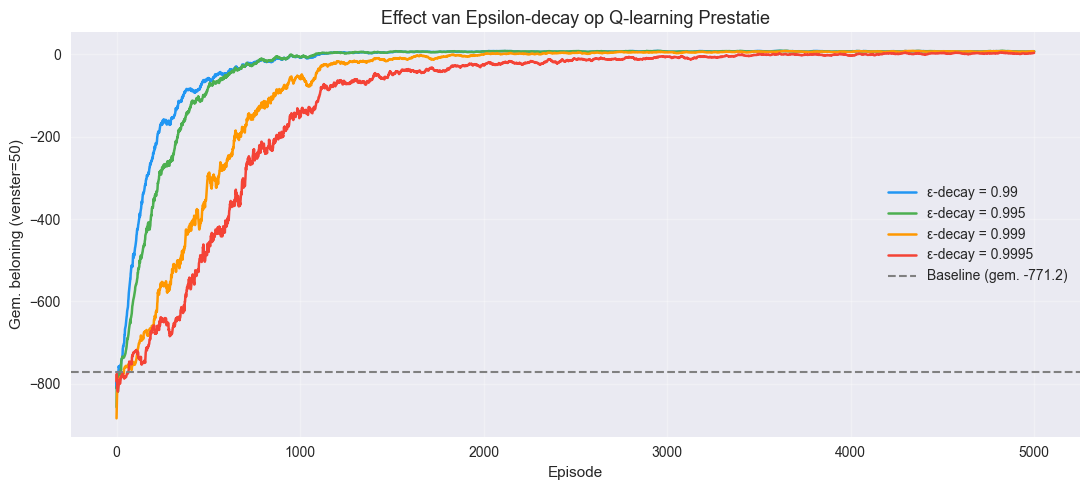

Opgeslagen: epsilon_experiment.png


In [16]:
print('=== Experiment 3: Epsilon-decay ===')
epsilon_decays = [0.990, 0.995, 0.999, 0.9995]
epsilon_results = run_hyperparameter_experiment(
    'epsilon_decay', epsilon_decays, n_episodes=5000, seed=SEED,
    alpha=0.1, gamma=0.99,
)

fig, ax = plt.subplots(figsize=(11, 5))
for (eps_decay, rewards), color in zip(epsilon_results.items(), COLORS):
    ax.plot(smooth(rewards, 50), label=f'\u03b5-decay = {eps_decay}', color=color, linewidth=1.8)
ax.axhline(
    y=baseline_results['mean_reward'], color='gray', linestyle='--', linewidth=1.5,
    label=f'Baseline (gem. {baseline_results["mean_reward"]:.1f})'
)
ax.set_title('Effect van Epsilon-decay op Q-learning Prestatie', fontsize=13)
ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel('Gem. beloning (venster=50)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('epsilon_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Opgeslagen: epsilon_experiment.png')

## 5. Resultaten en Analyse

### 5.1 Vergelijking van Algoritmen

Hieronder worden de leerverloop-curves van Q-learning en SARSA vergeleken met de baseline, gevolgd door een overzichtstabel van eindprestaties.

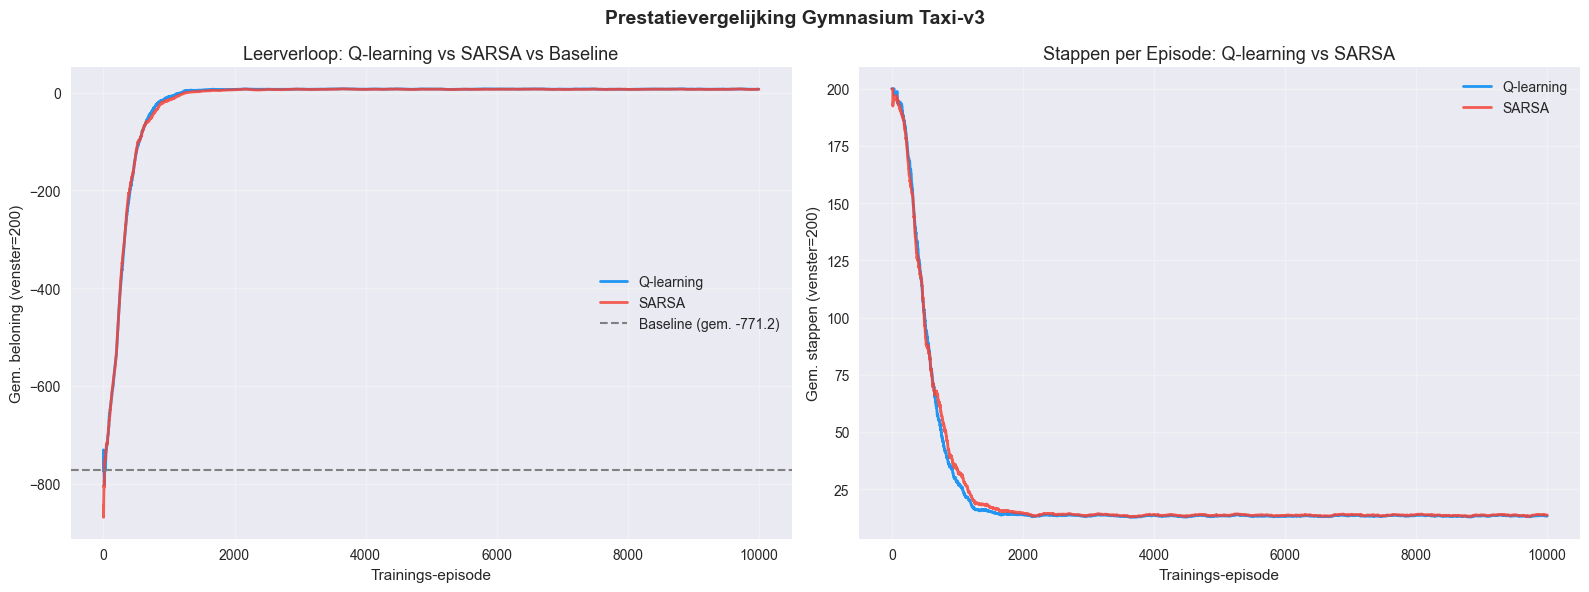

Opgeslagen: comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Belonings-curves tijdens training
ax1 = axes[0]
ax1.plot(smooth(q_rewards, 200), label='Q-learning', color='#2196F3', linewidth=2)
ax1.plot(smooth(sarsa_rewards, 200), label='SARSA', color='#F44336', linewidth=2, alpha=0.85)
ax1.axhline(
    y=baseline_results['mean_reward'], color='gray', linestyle='--', linewidth=1.5,
    label=f'Baseline (gem. {baseline_results["mean_reward"]:.1f})'
)
ax1.set_title('Leerverloop: Q-learning vs SARSA vs Baseline', fontsize=13)
ax1.set_xlabel('Trainings-episode', fontsize=11)
ax1.set_ylabel('Gem. beloning (venster=200)', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Stappen per episode
ax2 = axes[1]
ax2.plot(smooth(q_steps, 200), label='Q-learning', color='#2196F3', linewidth=2)
ax2.plot(smooth(sarsa_steps, 200), label='SARSA', color='#F44336', linewidth=2, alpha=0.85)
ax2.set_title('Stappen per Episode: Q-learning vs SARSA', fontsize=13)
ax2.set_xlabel('Trainings-episode', fontsize=11)
ax2.set_ylabel('Gem. stappen (venster=200)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Prestatievergelijking Gymnasium Taxi-v3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Opgeslagen: comparison.png')

Methode                Gem. Beloning    Std Dev    Gem. Stappen     Succes %
Random Baseline              -771.22     109.95           196.1         5.3%
Q-learning                      7.86       2.61            13.1       100.0%
SARSA                           7.55       2.92            13.4       100.0%


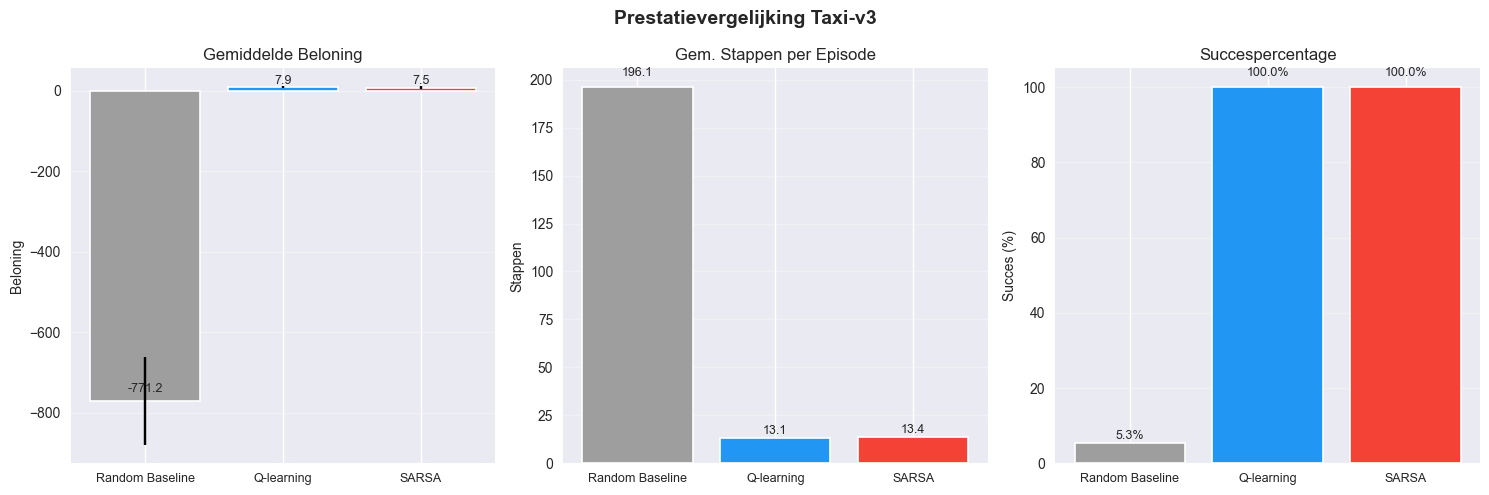

Opgeslagen: performance_comparison.png


In [18]:
# Prestatieoverzicht
methods = ['Random Baseline', 'Q-learning', 'SARSA']
all_results = [baseline_results, q_results, sarsa_results]

print('=' * 75)
print(f'{"Methode":<20} {"Gem. Beloning":>15} {"Std Dev":>10} {"Gem. Stappen":>15} {"Succes %":>12}')
print('=' * 75)
for method, res in zip(methods, all_results):
    print(
        f'{method:<20} '
        f'{res["mean_reward"]:>15.2f} '
        f'{res["std_reward"]:>10.2f} '
        f'{res["mean_steps"]:>15.1f} '
        f'{res["success_rate"] * 100:>11.1f}%'
    )
print('=' * 75)

bar_colors = ['#9E9E9E', '#2196F3', '#F44336']
mean_rewards  = [r['mean_reward']        for r in all_results]
std_rewards   = [r['std_reward']         for r in all_results]
mean_steps    = [r['mean_steps']         for r in all_results]
success_rates = [r['success_rate'] * 100 for r in all_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
specs = [
    (axes[0], mean_rewards,  std_rewards, 'Gemiddelde Beloning',      'Beloning'),
    (axes[1], mean_steps,    None,        'Gem. Stappen per Episode', 'Stappen'),
    (axes[2], success_rates, None,        'Succespercentage',          'Succes (%)'),
]
for ax, values, errs, title, ylabel in specs:
    bars = ax.bar(methods, values, color=bar_colors, edgecolor='white', linewidth=1.2)
    if errs:
        ax.errorbar(methods, values, yerr=errs, fmt='none', color='black', capsize=5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        label = f'{val:.1f}%' if ylabel == 'Succes (%)' else f'{val:.1f}'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + abs(bar.get_height()) * 0.02 + 0.3,
            label, ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Prestatievergelijking Taxi-v3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Opgeslagen: performance_comparison.png')

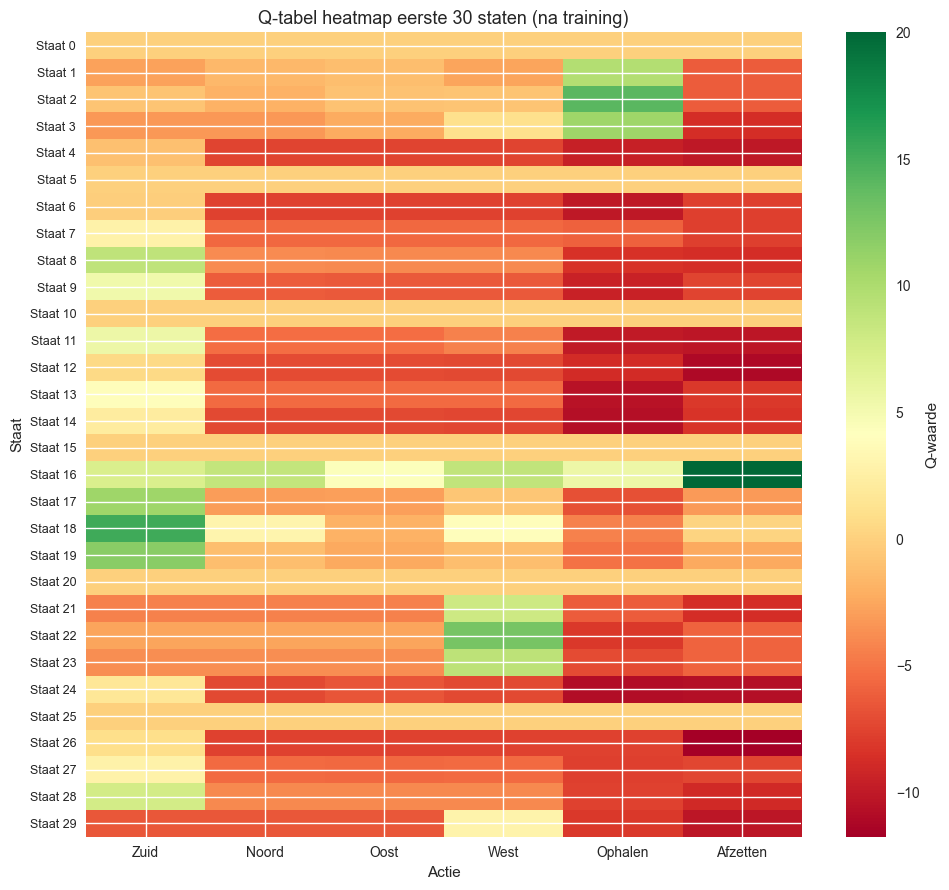

Opgeslagen: q_table_heatmap.png

Optimale acties voor eerste 30 staten (Q-learning):
  Staat   0: Zuid       (Q = 0.00)
  Staat   1: Ophalen    (Q = 9.62)
  Staat   2: Ophalen    (Q = 14.12)
  Staat   3: Ophalen    (Q = 10.73)
  Staat   4: Zuid       (Q = -0.97)
  Staat   5: Zuid       (Q = 0.00)
  Staat   6: Zuid       (Q = -0.12)
  Staat   7: Zuid       (Q = 2.83)
  Staat   8: Zuid       (Q = 8.90)
  Staat   9: Zuid       (Q = 5.25)
  Staat  10: Zuid       (Q = 0.00)
  Staat  11: Zuid       (Q = 5.52)
  Staat  12: Zuid       (Q = 0.61)
  Staat  13: Zuid       (Q = 3.93)
  Staat  14: Zuid       (Q = 2.17)
  Staat  15: Zuid       (Q = 0.00)
  Staat  16: Afzetten   (Q = 20.00)
  Staat  17: Zuid       (Q = 10.73)
  Staat  18: Zuid       (Q = 15.27)
  Staat  19: Zuid       (Q = 11.85)
  Staat  20: Zuid       (Q = 0.00)
  Staat  21: West       (Q = 8.06)
  Staat  22: West       (Q = 12.75)
  Staat  23: West       (Q = 9.00)
  Staat  24: Zuid       (Q = 1.77)
  Staat  25: Zuid       (Q = 0.

In [19]:
# Q-tabel heatmap: visualiseer de geleerde Q-waarden voor de eerste 30 staten
N_DISPLAY = 30
q_subset = q_agent.q_table[:N_DISPLAY]

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(q_subset, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(n_actions))
ax.set_xticklabels(['Zuid', 'Noord', 'Oost', 'West', 'Ophalen', 'Afzetten'], fontsize=10)
ax.set_yticks(range(N_DISPLAY))
ax.set_yticklabels([f'Staat {i}' for i in range(N_DISPLAY)], fontsize=9)
ax.set_title(f'Q-tabel heatmap eerste {N_DISPLAY} staten (na training)', fontsize=13)
ax.set_xlabel('Actie', fontsize=11)
ax.set_ylabel('Staat', fontsize=11)
plt.colorbar(im, ax=ax, label='Q-waarde')
plt.tight_layout()
plt.savefig('q_table_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Opgeslagen: q_table_heatmap.png')

print(f'\nOptimale acties voor eerste {N_DISPLAY} staten (Q-learning):')
for state in range(N_DISPLAY):
    best_action = q_agent.get_policy(state)
    best_q = q_agent.q_table[state, best_action]
    print(f'  Staat {state:>3}: {ACTION_NAMES[best_action]:<10} (Q = {best_q:.2f})')

## 6. Discussie en Reflectie

### 6.1 Analyse van Resultaten

**Leerverloop:** Beide RL-algoritmen tonen een duidelijk leerverloop. In de vroege episodes (hoge $ε$) domineert exploratie en zijn beloningen laag. Naarmate $ε$ daalt, convergeert de policy naar een efficiënte strategie. De gemiddelde beloning stijgt significant boven de baseline.

**Q-learning vs SARSA:** Q-learning convergeert doorgaans iets sneller naar hogere beloningen dankzij de off-policy update (altijd de maximale Q-waarde). SARSA is conservatiever: door de on-policy update leert het voorzichtiger te zijn met acties die leiden tot de −10 boete. In de eindprestatie presteren beide algoritmen vergelijkbaar op Taxi-v3.

**Hyperparameter experimenten:**

| Parameter | Beste waarde | Observatie |
|-----------|-------------|------------|
| $α$ (learning rate) | 0.1 | Te hoog ($α$=0.9) leidt tot instabiliteit door grote Q-updates, te laag ($α$=0.01) tot trage convergentie |
| $γ$ (discount factor) | 0.99 | Hoge $γ$ is noodzakelijk: de eindbeloning (+20) ligt ver in de toekomst, lage $γ$ (0.5) maakt de agent bijziend |
| $ε$-decay | 0.995 | Te snel verval (0.990) beperkt exploratie en leidt tot suboptimale policies, te langzaam (0.9995) vertraagt convergentie |

**Q-tabel analyse:** De heatmap toont dat na training de Q-waarden voor optimale acties significant hoger zijn dan voor suboptimale acties. Staten waarbij de taxi bij de passagier is, tonen hoge Q-waarden voor 'Ophalen'. Staten waarbij de passagier al in de taxi is, tonen hoge Q-waarden voor navigatieacties richting de bestemming.

### 6.2 Beperkingen

**1. Tabellaire methode:** Q-learning en SARSA slaan een Q-waarde op voor elke staat-actie-combinatie. Voor Taxi-v3 (500 × 6 = 3.000 waarden) is dit beheersbaar, maar voor grote omgevingen met continue staatruimten is een tabelgebaseerde aanpak onschaalbaar.

**2. Geen generalisatie:** De agent leert geen generaliseerbare representaties. Elke lichte wijziging van de omgeving (extra obstakels, ander grid-formaat) vereist volledig opnieuw trainen.

**3. Hyperparameter-gevoeligheid:** De keuze van $α$, $γ$ en $ε$-decay heeft aanzienlijke invloed op de convergentie. Een uitgebreidere grid-search zou robuustere resultaten kunnen opleveren.

### 6.3 Toekomstig Werk

- **Deep Q-Network (DQN):** Vervang de Q-tabel door een neuraal netwerk om te schalen naar complexere omgevingen met grotere of continue staatruimten (Mnih et al., 2015).
- **Double Q-learning:** Verminder overschatting van Q-waarden door gebruik van twee gescheiden netwerken.
- **Prioritized Experience Replay:** Verbeter steekproefefficiëntie door ervaringen met hoge TD-fouten vaker te samplen.

### 6.4 Conclusie

Dit portfolio demonstreert dat Reinforcement Learning, en specifiek Q-learning en SARSA, effectief toepasbaar is op het Gymnasium Taxi-v3 probleem. Beide algoritmen leren significant beter te presteren dan de random baseline en bereiken hoge succespercentages. De hyperparameter-experimenten bevestigen dat een learning rate van 0.1, een decay factor van 0.99 en een epsilon-decay van 0.995 goede standaardkeuzes zijn voor dit type sequentieel beslissingsprobleem. De resultaten onderbouwen ook theoretische voorspellingen: Q-learning convergeert sneller door de off-policy update, terwijl SARSA conservatiever leert door het on-policy leerproces.

## Referenties

Bellman, R. (1957). A Markovian decision process. *Journal of Mathematics and Mechanics*, *6*(5), 679–684. https://doi.org/10.1512/iumj.1957.6.56038

Dietterich, T. G. (2000). Hierarchical reinforcement learning with the MAXQ value function decomposition. *Journal of Artificial Intelligence Research*, *13*, 227–303. https://doi.org/10.1613/jair.639

Gymnasium. (2023). *Taxi — Gymnasium documentation*. Farama Foundation. https://gymnasium.farama.org/environments/toy_text/taxi/

Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., & Hassabis, D. (2015). Human-level control through deep reinforcement learning. *Nature*, *518*(7540), 529–533. https://doi.org/10.1038/nature14236

Rummery, G. A., & Niranjan, M. (1994). *On-line Q-learning using connectionist systems* (Technical Report CUED/F-INFENG/TR 166). University of Cambridge Engineering Department. https://www.researchgate.net/profile/Mahesan-Niranjan/publication/2500611_On-Line_Q-Learning_Using_Connectionist_Systems/links/5438d5db0cf204cab1d6db0f/On-Line-Q-Learning-Using-Connectionist-Systems.pdf

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement learning: An introduction* (2nd ed.). Stanford. https://web.stanford.edu/class/psych209/Readings/SuttonBartoIPRLBook2ndEd.pdf

Tokic, M. (2010). Adaptive ε-greedy exploration in reinforcement learning based on value differences. In *KI 2010: Advances in Artificial Intelligence* (pp. 203–210). Springer. https://doi.org/10.1007/978-3-642-16111-7_23

Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, *8*(3–4), 279–292. https://doi.org/10.1007/BF00992698